# Treino com o dataset dos EUA

Treino dos três modelos com os dados gerados em `02_preparacao_dados.ipynb` (~17,6 milhões de linhas de treino).

Na primeira tentativa, no Google Colab, o Random Forest com árvores de profundidade ilimitada esgotou a memória e o
tempo de sessão. Aqui cada árvore é treinada com uma amostra de 10% dos dados e folhas de pelo menos 10 exemplos,
o que o torna viável num computador comum. O gráfico de previsões usa uma amostra de 100 mil pontos do teste.

In [1]:
from pathlib import Path

import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from flight_prices.evaluation import (
    fit_and_predict,
    metrics_table,
    plot_error_comparison,
    plot_feature_importance,
    plot_predictions_vs_actual,
    plot_residuals,
)

DATA_DIR = Path("../data")
UNIT = "USD"
XGB_DEVICE = "cpu"

In [2]:
data = np.load(DATA_DIR / "treino_eua.npz", allow_pickle=True)
X_train, X_test, y_train, y_test = (data[key] for key in ("X_train", "X_test", "y_train", "y_test"))
feature_names = list(data["features"])

In [3]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_samples=0.1, min_samples_leaf=10, random_state=42, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42, tree_method="hist", device=XGB_DEVICE),
}

predictions = fit_and_predict(models, X_train, y_train, X_test)

Linear Regression: treinado em 6.51s


Random Forest: treinado em 409.60s


XGBoost: treinado em 190.74s


In [4]:
metrics = metrics_table(y_test, predictions, UNIT)
metrics

,MAE (USD),RMSE (USD),R²
Linear Regression,94.936028,147.600872,0.196040
Random Forest,52.283813,101.541195,0.619512
XGBoost,61.632206,109.668770,0.556164


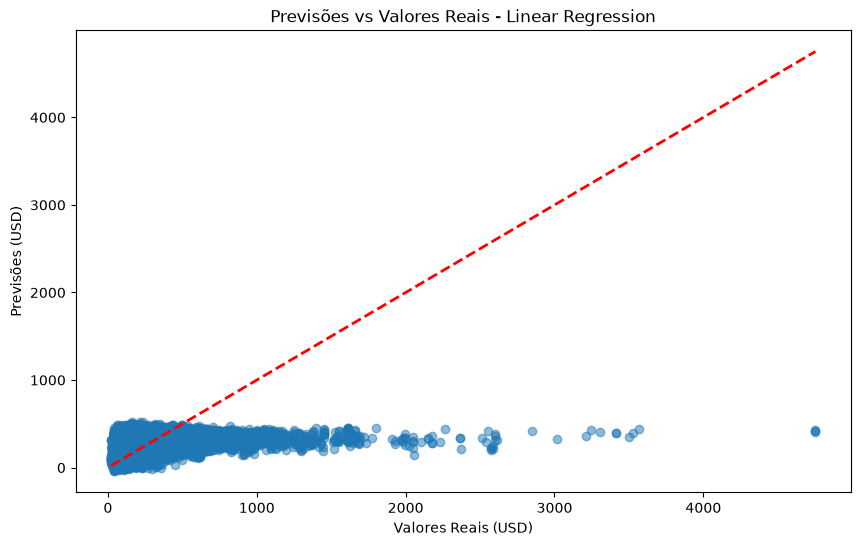

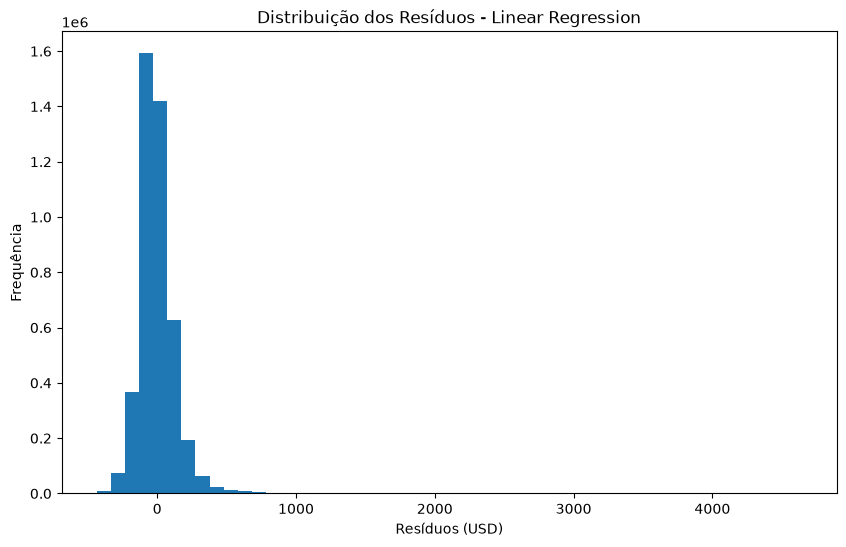

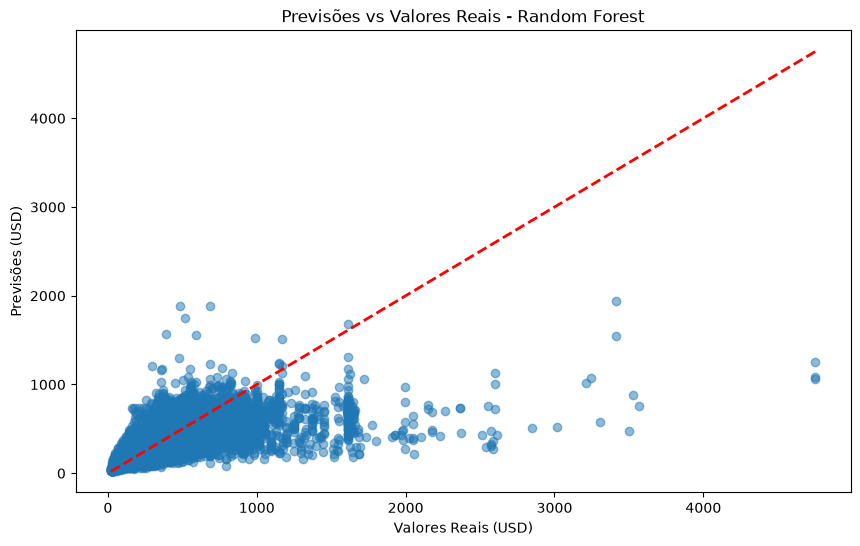

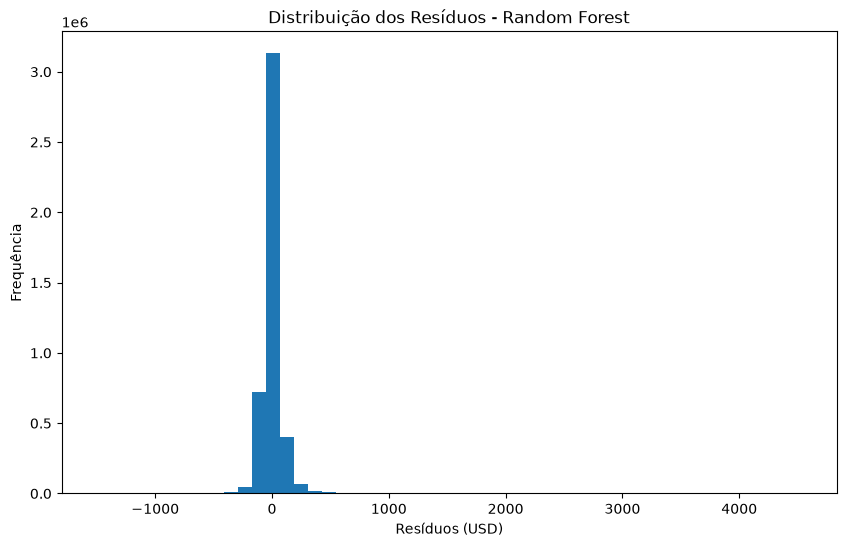

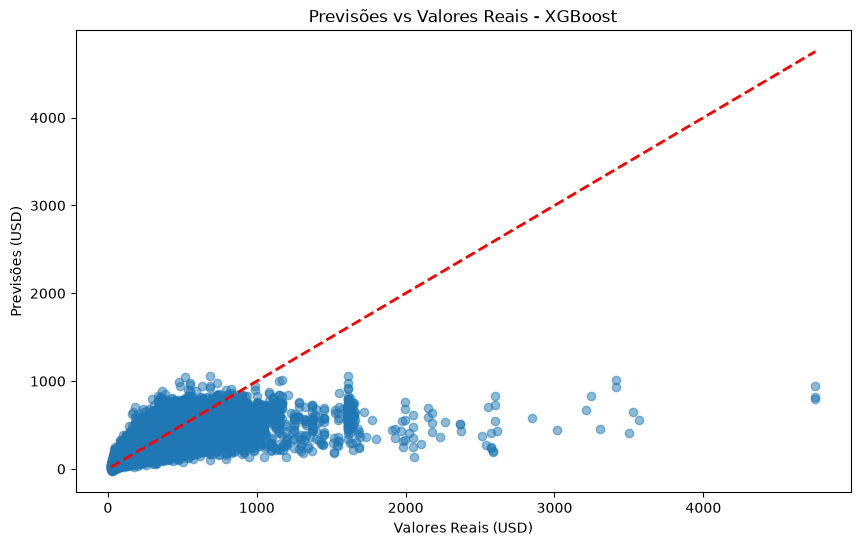

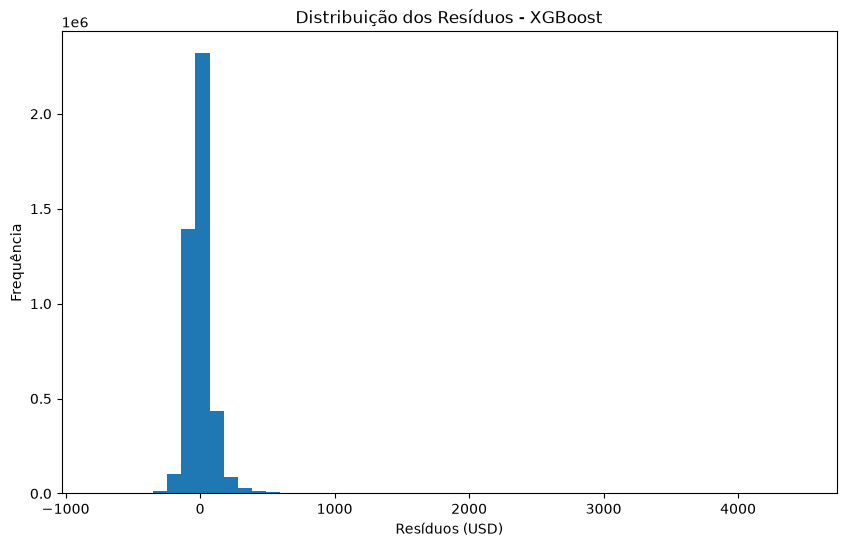

In [5]:
for name, y_pred in predictions.items():
    plot_predictions_vs_actual(name, y_test, y_pred, UNIT, max_points=100_000)
    plot_residuals(name, y_test, y_pred, UNIT)

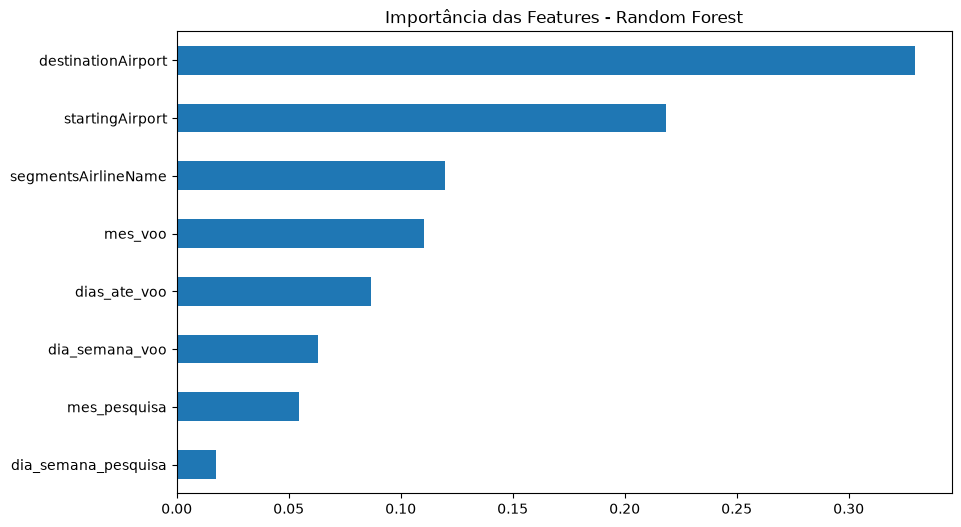

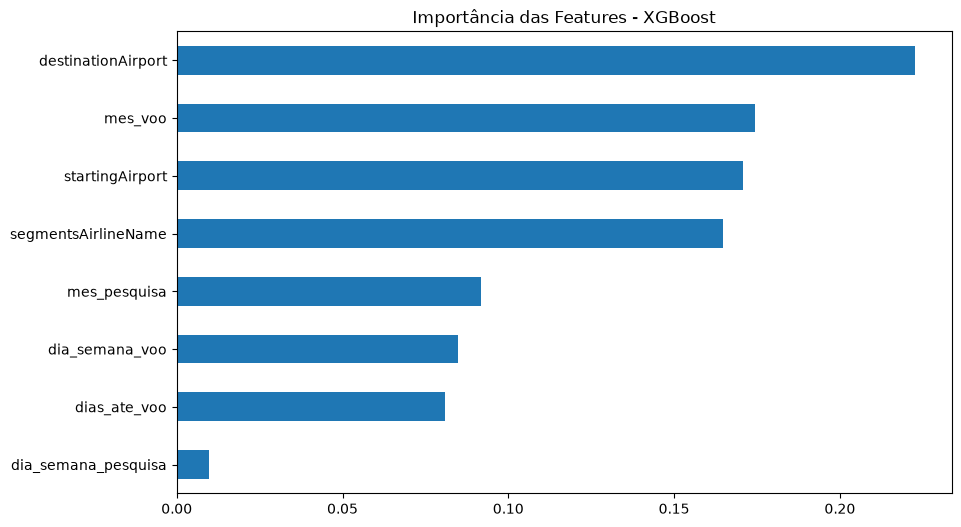

In [6]:
for name in ("Random Forest", "XGBoost"):
    plot_feature_importance(name, models[name], feature_names)

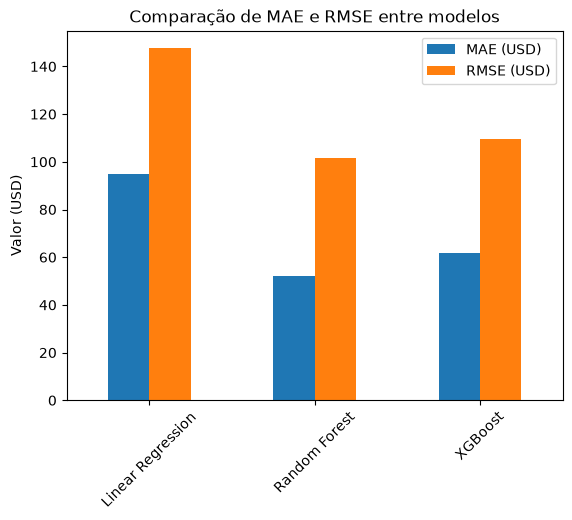

In [7]:
plot_error_comparison(metrics, UNIT)